Dataset successfully load ho gaya hai!



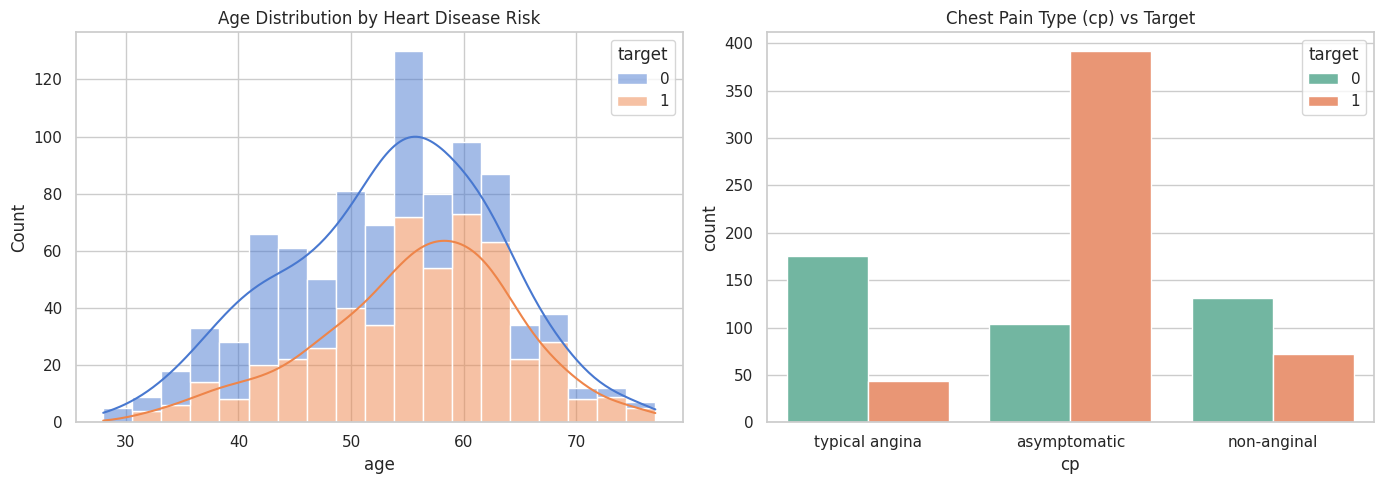


--- Model Evaluation ---
Accuracy Score: 82.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        82
           1       0.84      0.85      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



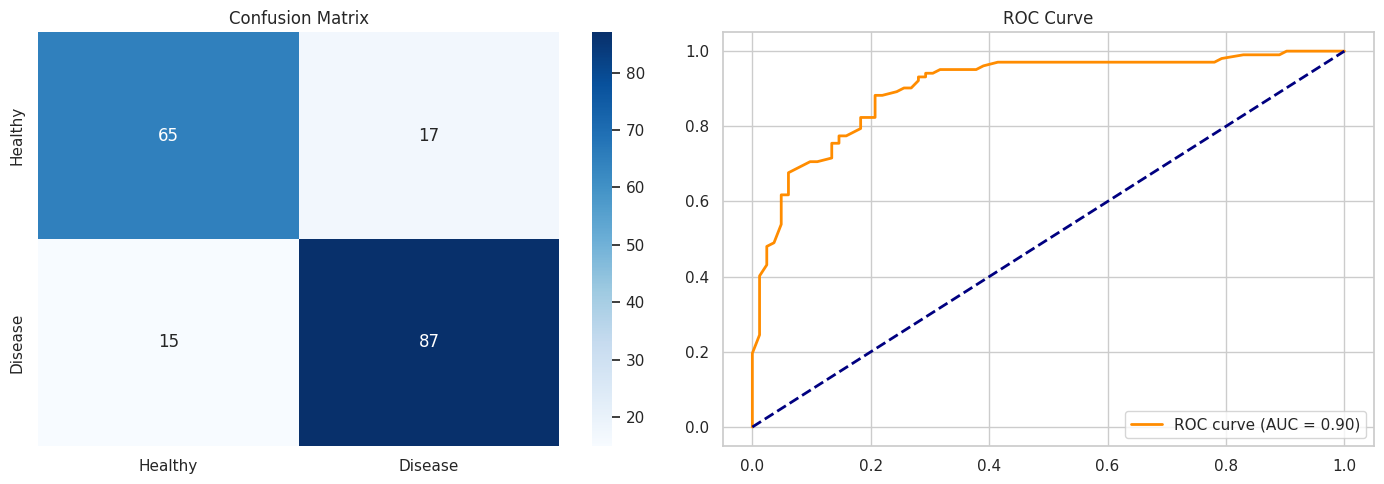

/tmp/ipykernel_777/609848734.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="magma")


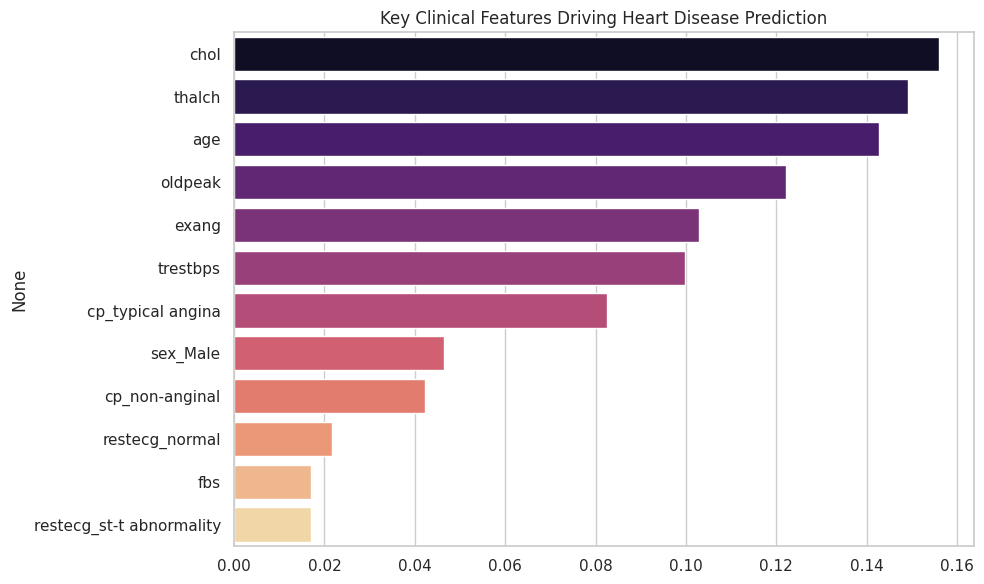

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. Loading and Cleaning Your Uploaded Dataset
# =====================================================================
file_name = "Heart Disease UCI Dataset.csv"

try:
    df = pd.read_csv(file_name)
    print("Dataset successfully load ho gaya hai!\n")

    # Column names ko lowercase karna consistency ke liye
    df.columns = df.columns.str.lower()

    # Target column rename karna agar zaroorat ho
    if "num" in df.columns:
        df.rename(columns={"num": "target"}, inplace=True)
        df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

    df = df.dropna()

    # =====================================================================
    # 2. Exploratory Data Analysis (EDA)
    # =====================================================================
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot A: Age distribution
    sns.histplot(data=df, x="age", hue="target", kde=True, multiple="stack", ax=axes[0], palette="muted")
    axes[0].set_title("Age Distribution by Heart Disease Risk")

    # Plot B: Chest Pain Type vs Target (Handles both string and numeric types)
    if "cp" in df.columns:
        sns.countplot(data=df, x="cp", hue="target", ax=axes[1], palette="Set2")
        axes[1].set_title("Chest Pain Type (cp) vs Target")

    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 3. Handling Text/String Columns (FIX FOR THE VALUEERROR)
    # =====================================================================
    # Is step mein hum 'Female'/'Male' jaise text columns ko 0 aur 1 mein convert kar rahe hain
    X = df.drop(columns=["target"])
    y = df["target"]

    # pd.get_dummies string columns ko numeric indicators mein convert kar deta hai
    X = pd.get_dummies(X, drop_first=True)

    # =====================================================================
    # 4. Model Training
    # =====================================================================
    # Stratified split taaki train aur test dono mein balanced classes hon
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # =====================================================================
    # 5. Model Evaluation
    # =====================================================================
    print("\n--- Model Evaluation ---")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Healthy", "Disease"], yticklabels=["Healthy", "Disease"])
    axes[0].set_title("Confusion Matrix")

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.2f})")
    axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    axes[1].set_title("ROC Curve")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 6. Feature Importance
    # =====================================================================
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=X.columns[indices], palette="magma")
    plt.title("Key Clinical Features Driving Heart Disease Prediction")
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: '{file_name}' file nahi mili.")